### Step 1: 讀取圖片並轉換矩陣格式

彩色圖片維度 (m x n x 3): (4284, 5712, 3)
灰階圖片維度 (m x n): (4284, 5712)


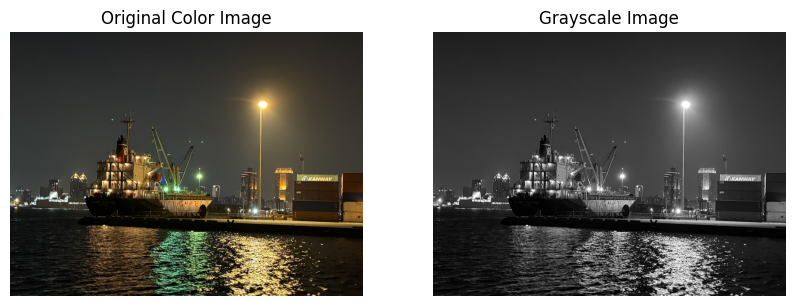

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 1. 讀取彩色圖片並轉為 Numpy 陣列
img_color = Image.open("my_image.jpg")
A_color = np.array(img_color)

# 2. 將圖片轉換為灰階並轉為 Numpy 陣列
img_gray = img_color.convert("L")
A_gray = np.array(img_gray)

# 顯示圖片維度資訊
print(f"彩色圖片維度 (m x n x 3): {A_color.shape}")
print(f"灰階圖片維度 (m x n): {A_gray.shape}")

# 顯示原圖與灰階圖
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(A_color)
ax[0].set_title("Original Color Image")
ax[0].axis('off')

ax[1].imshow(A_gray, cmap='gray')
ax[1].set_title("Grayscale Image")
ax[1].axis('off')

plt.show()

### Step 2: 奇異值分解 (Singular Value Decomposition) 與最佳逼近

在進行程式碼實作前，我們首先確立 SVD 的數學定義。對於任意影像矩陣 $A \in \mathbb{R}^{m \times n}$，我們可以將其進行奇異值分解：

$$A = U \Sigma V^T$$

其中：
* $U = [u_1, u_2, ..., u_m]$ 是一個 $m \times m$ 的正交矩陣 (Orthogonal Matrix)，其行向量稱為左奇異向量 (Left Singular Vectors)。
* $\Sigma = \text{diag}[\sigma_1, \sigma_2, ..., \sigma_p]$ 是一個 $m \times n$ 的對角矩陣，對角線上的元素 $\sigma_i$ 即為奇異值 (Singular Values)，且依降序排列。這裡的 $p = \min\{m, n\}$。
* $V = [v_1, v_2, ..., v_n]$ 是一個 $n \times n$ 的正交矩陣，其行向量稱為右奇異向量 (Right Singular Vectors)。

**降維與影像壓縮 (Rank-$k$ Approximation)**

為了達到壓縮圖片的目的，我們選取前 $k$ 個最重要的奇異值 ($0 < k < p$)，來建構一個新的矩陣 $A_k$。這可以表示為前 $k$ 個 Rank-1 矩陣的線性組合：

$$A_k = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

**Eckart-Young-Mirsky 定理 (誤差估計)**

根據最佳逼近理論，在所有秩為 $k$ 的矩陣中，$A_k$ 是在 2-norm 意義下最接近原矩陣 $A$ 的解。其捨棄掉的資訊量（即截斷誤差）精準地等於第 $k+1$ 個奇異值：

$$||A - A_k||_2 = \sigma_{k+1}$$

我們接下來將透過 Python 實作來驗證此數學定理。

---

In [3]:
def svd_restore(image, k):
    """
    對圖片矩陣進行 SVD 分解，並保留前 k 個奇異值進行重建。
    """
    # 1. 執行 SVD 分解 (full_matrices=False 表示使用精簡版 SVD，加快運算並節省記憶體)
    u, sigma, vt = np.linalg.svd(image, full_matrices=False)
    
    # 2. 避免 k 值超出奇異值的數量上限
    k = min(len(sigma) - 1, k)
    
    # 3. 依照 k 值，擷取前 k 個特徵並重建新的圖形矩陣 Ak
    # 這裡對應數學式：Ak = U_k * Sigma_k * V^T_k
    Ak = np.dot(u[:, :k], np.dot(np.diag(sigma[:k]), vt[:k, :]))
    
    # 4. 處理溢位問題：數學運算後可能會有微小誤差導致數值超出 0~255 的範圍
    Ak[Ak < 0] = 0
    Ak[Ak > 255] = 255
    
    # 5. 將浮點數四捨五入，並轉型為圖片所需的 uint8 格式
    Ak = np.rint(Ak).astype('uint8')
    
    # 我們順便回傳完整的 sigma 陣列，這對驗證 Step 3 非常重要！
    return Ak, sigma

#### 2-norm

In [4]:
def calculate_2norm(A, Ak):
    """
    計算原圖矩陣 A 與壓縮圖矩陣 Ak 之間的 2-norm 誤差 (||A - Ak||_2)
    """
    return np.linalg.norm(A - Ak, 2)

### Step 3: 驗證最佳逼近理論 (Error Estimate)

根據理論，我們知道截斷前 $k$ 個奇異值所造成的 2-norm 誤差，會剛好等於第 $k+1$ 個奇異值。

為了驗證此事，我們將設定一組不同的 $k$ 值陣列（例如 $k = 1, 5, 10, 20...$ 等），針對我們的「灰階圖片矩陣」進行 SVD 分解與重建，並計算出實際的 $||A - A_k||_2$ 數值，與理論的 $\sigma_{k+1}$ 進行嚴格比對。

> **注意**：為了驗證純數學的等式，我們在計算 2-norm 誤差時，不對矩陣進行 `uint8` 的轉型與四捨五入（即不截斷小數點），以保留浮點數的精確度。

In [5]:
import pandas as pd

# 定義要測試的 k 值範圍
k_values = [1, 5, 10, 15, 20, 30, 50, 80, 100, 150, 200, 300, 500]

# 準備一個列表來儲存驗證結果
validation_results = []

# 為了驗證純數學，我們對原本的灰階矩陣做一次完整的 SVD，並強制轉為 float64 確保精度
A_float = A_gray.astype(np.float64)
U, Sigma, VT = np.linalg.svd(A_float, full_matrices=False)

for k in k_values:
    # 確保 k 不會超出 Sigma 的數量
    if k >= len(Sigma):
        break
        
    # 1. 產生純數學上的近似矩陣 Ak (不轉 uint8，不限制 0~255)
    Ak_math = np.dot(U[:, :k], np.dot(np.diag(Sigma[:k]), VT[:k, :]))
    
    # 2. 計算實際的 2-norm 誤差: ||A - Ak||_2
    error_2norm = calculate_2norm(A_float, Ak_math)
    
    # 3. 取得理論上的誤差: 第 k+1 個奇異值 (在 Python 陣列中索引為 k)
    sigma_k_plus_1 = Sigma[k]
    
    # 將結果記錄下來
    validation_results.append({
        "K 值": k,
        "2-norm 誤差 (||A - Ak||_2)": error_2norm,
        "Sigma_{k+1}": sigma_k_plus_1,
        "是否相等 (誤差<1e-8)": abs(error_2norm - sigma_k_plus_1) < 1e-8
    })

# 轉換成 DataFrame 並顯示，排版會非常精美
df_validation = pd.DataFrame(validation_results)
display(df_validation)

,K 值,2-norm 誤差 (||A - Ak||_2),Sigma_{k+1},是否相等 (誤差<1e-8)
0,1,79424.067571,79424.067571,True
1,5,31805.778754,31805.778754,True
2,10,23433.441012,23433.441012,True
3,15,19155.022132,19155.022132,True
4,20,16469.706196,16469.706196,True
5,30,13760.848381,13760.848381,True
6,50,10171.634130,10171.634130,True
7,80,7345.392036,7345.392036,True
8,100,6086.123901,6086.123901,True
9,150,4245.491586,4245.491586,True
